In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import requests
import time

In [2]:
df = pd.read_csv("saudi_weather.csv")

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29583 entries, 0 to 29582
Data columns (total 26 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   time                         29583 non-null  object 
 1   weather_code                 29583 non-null  int64  
 2   temperature_2m_mean          29583 non-null  float64
 3   temperature_2m_max           29583 non-null  float64
 4   temperature_2m_min           29583 non-null  float64
 5   apparent_temperature_mean    29583 non-null  float64
 6   apparent_temperature_max     29583 non-null  float64
 7   apparent_temperature_min     29583 non-null  float64
 8   precipitation_sum            29583 non-null  float64
 9   rain_sum                     29583 non-null  float64
 10  precipitation_hours          29583 non-null  float64
 11  wind_speed_10m_mean          29583 non-null  float64
 12  wind_speed_10m_max           29583 non-null  float64
 13  wind_gusts_10m_m

In [4]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 29583
Columns: 26


In [5]:
df.describe()

,weather_code,temperature_2m_mean,temperature_2m_max,temperature_2m_min,apparent_temperature_mean,apparent_temperature_max,apparent_temperature_min,precipitation_sum,rain_sum,precipitation_hours,...,wind_direction_10m_dominant,relative_humidity_2m_mean,relative_humidity_2m_max,relative_humidity_2m_min,dew_point_2m_mean,pressure_msl_mean,surface_pressure_mean,cloud_cover_mean,latitude,longitude
count,29583.000000,29583.000000,29583.000000,29583.000000,29583.000000,29583.000000,29583.000000,29583.000000,29583.00000,29583.000000,...,29583.000000,29583.000000,29583.000000,29583.000000,29583.000000,29583.000000,29583.000000,29583.000000,29583.000000,29583.000000
mean,11.594260,24.230954,30.062249,18.435547,22.074739,27.971359,16.271037,0.433208,0.43306,0.772302,...,186.817632,38.430010,57.153128,22.370145,5.787391,1012.181189,913.851830,24.718622,23.949151,43.330090
std,20.676776,8.203385,8.826248,7.567432,8.672426,9.259261,8.309650,2.130987,2.13013,2.338027,...,109.652280,20.838998,25.940538,15.707336,6.683055,6.395565,74.533938,26.214578,4.647494,3.160094
min,0.000000,2.400000,6.100000,-5.500000,-3.400000,1.700000,-10.000000,0.000000,0.00000,0.000000,...,0.000000,4.000000,8.000000,1.000000,-28.300000,992.400000,781.200000,0.000000,17.493260,39.825630
25%,0.000000,17.500000,22.800000,12.300000,15.100000,20.600000,9.800000,0.000000,0.00000,0.000000,...,81.000000,20.000000,33.000000,10.000000,1.000000,1007.500000,872.000000,1.000000,20.012880,41.038080
50%,3.000000,23.800000,29.700000,18.400000,21.700000,27.700000,16.400000,0.000000,0.00000,0.000000,...,203.000000,35.000000,57.000000,17.000000,5.300000,1012.900000,944.900000,16.000000,24.687730,42.505280
75%,3.000000,31.600000,38.000000,24.800000,29.500000,36.000000,22.900000,0.000000,0.00000,0.000000,...,289.000000,54.000000,80.000000,30.000000,10.000000,1017.100000,956.000000,41.000000,26.434420,44.127660
max,75.000000,41.200000,48.300000,37.500000,44.800000,49.700000,42.600000,68.700000,68.70000,24.000000,...,360.000000,99.000000,100.000000,96.000000,28.200000,1031.200000,1026.900000,100.000000,30.975310,50.103260


In [6]:
null = df.isnull().sum()
null

,0
time,0
weather_code,0
temperature_2m_mean,0
temperature_2m_max,0
temperature_2m_min,0
apparent_temperature_mean,0
apparent_temperature_max,0
apparent_temperature_min,0
precipitation_sum,0
rain_sum,0


In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df['city'].value_counts()

,count
city,
Riyadh,3287
Mecca,3287
Najran,3287
Al Bahah,3287
Sakaka,3287
Buraydah,3287
Abha,3287
Dammam,3287
Arar,3287


In [9]:
df['weather_code'].value_counts()

,count
weather_code,
3,10237
0,8117
51,2892
2,2867
1,2738
53,1141
61,702
63,443
55,392


# Visualizations


---



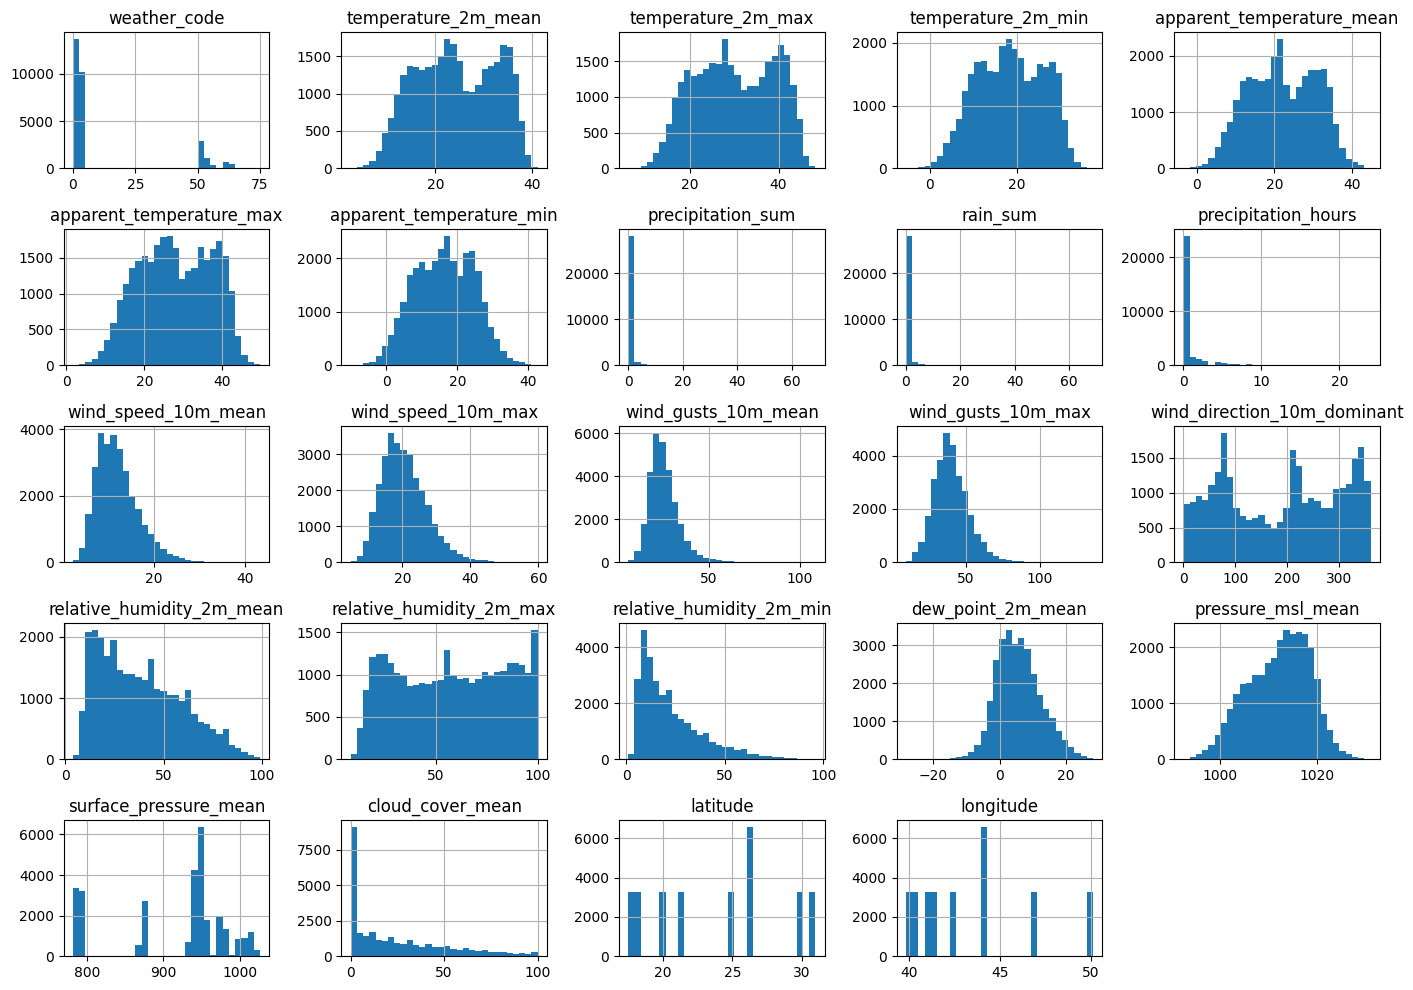

In [10]:
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

# Plot histograms
df[numeric_cols].hist(figsize=(14, 10), bins=30)

plt.tight_layout()
plt.show()

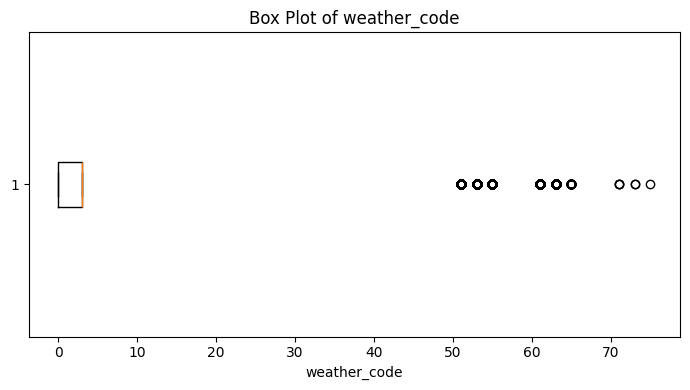

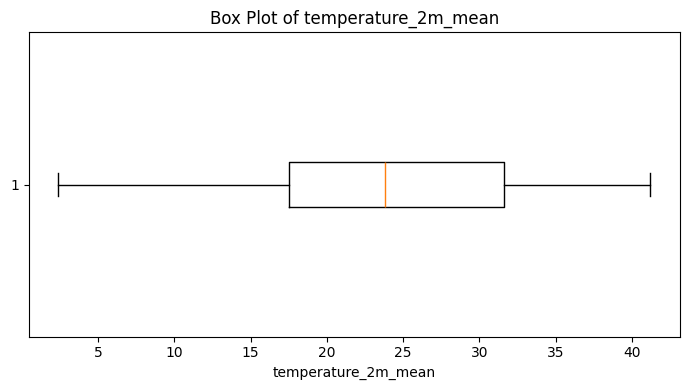

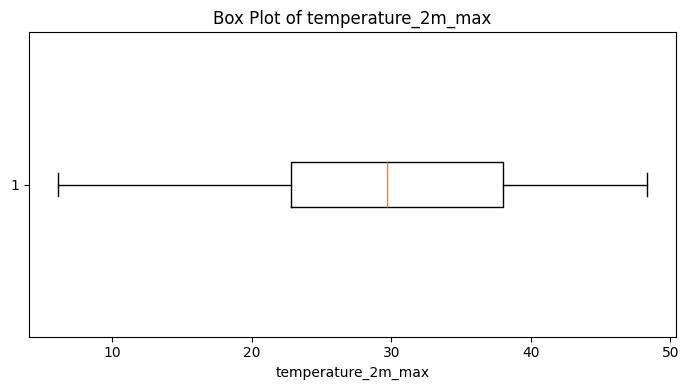

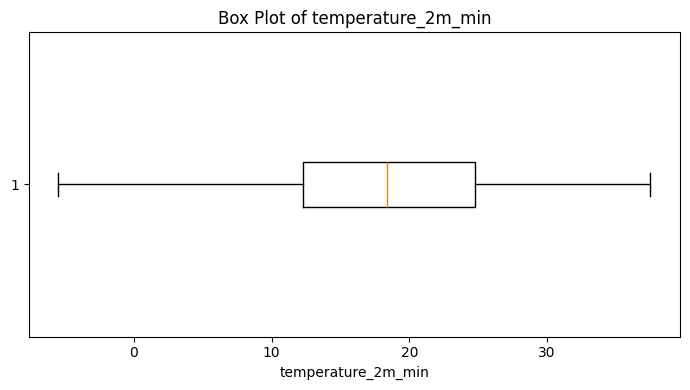

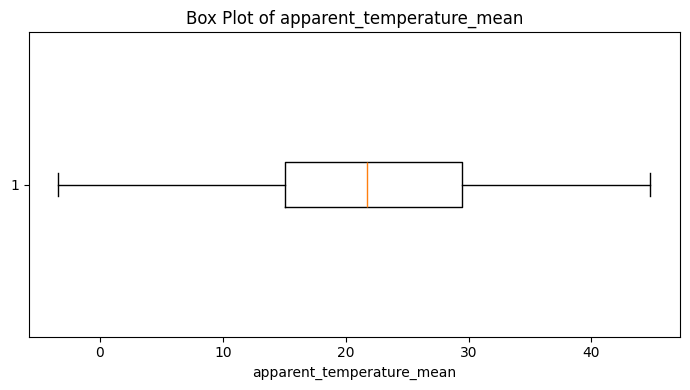

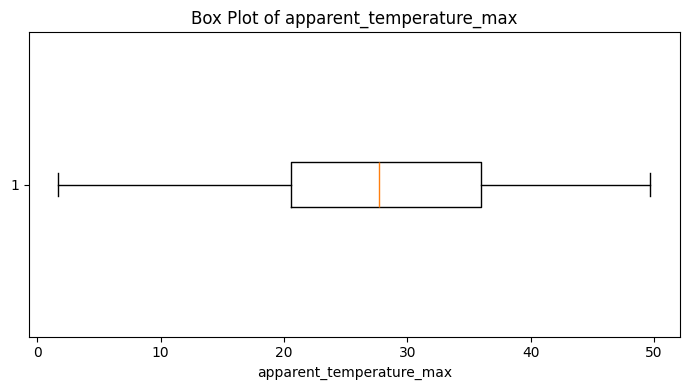

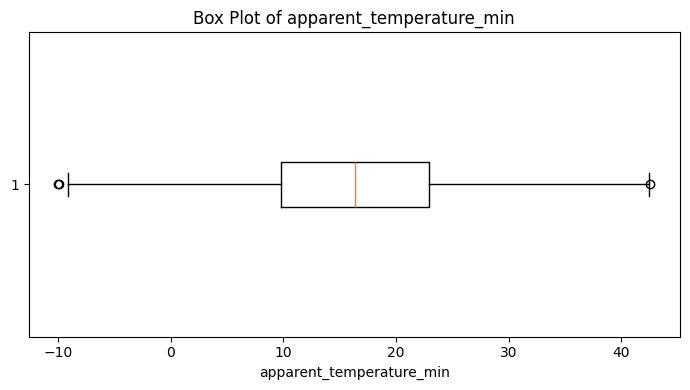

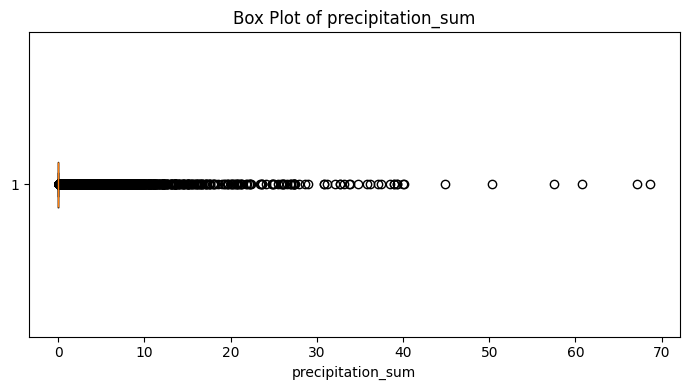

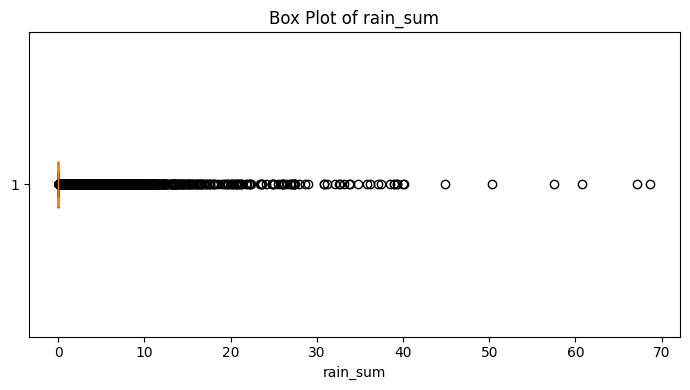

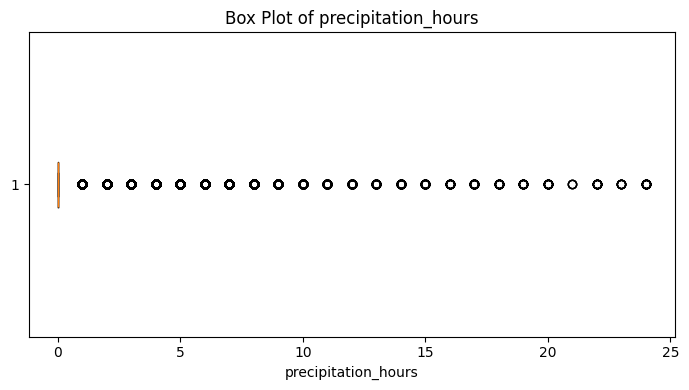

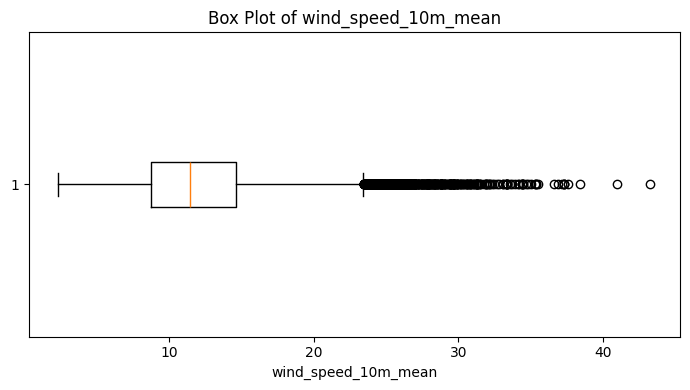

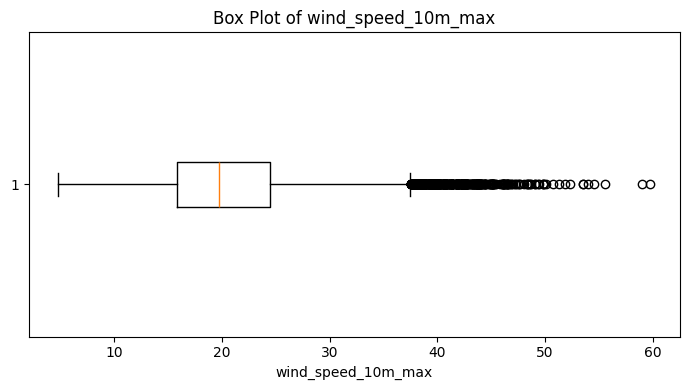

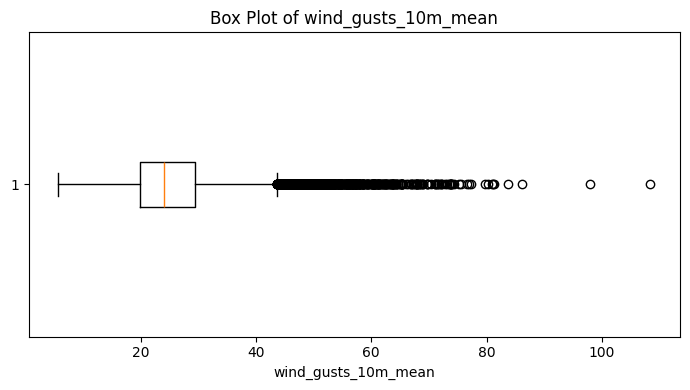

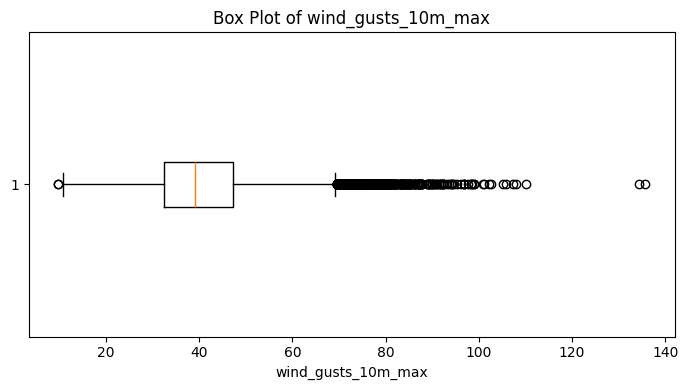

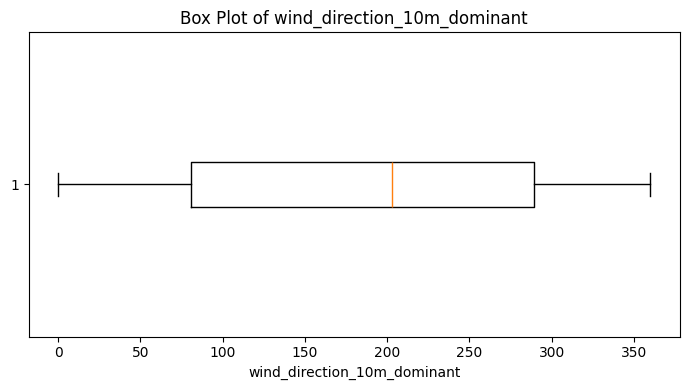

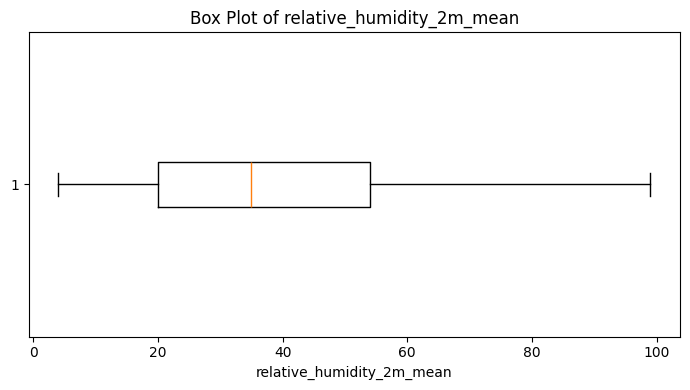

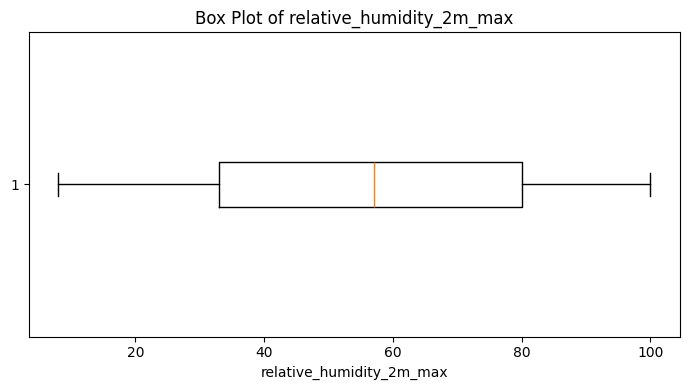

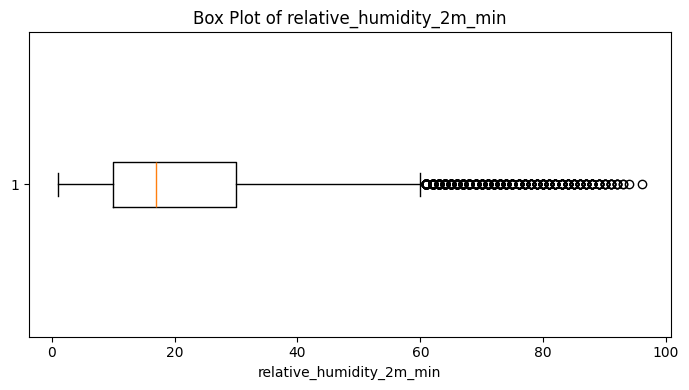

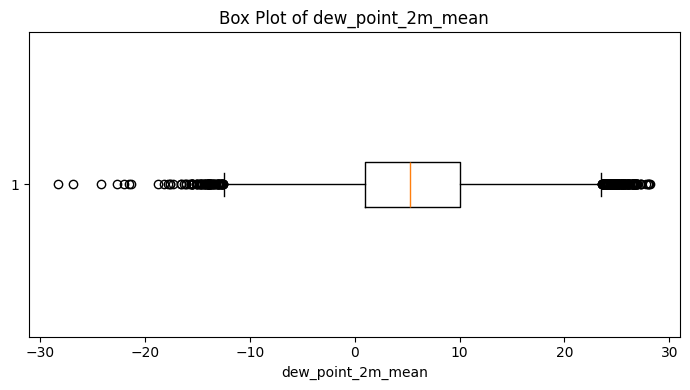

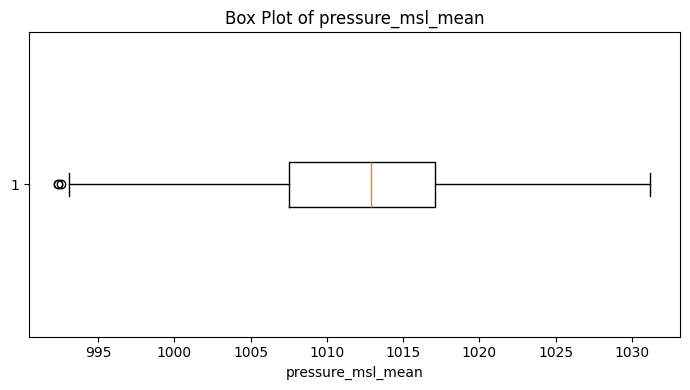

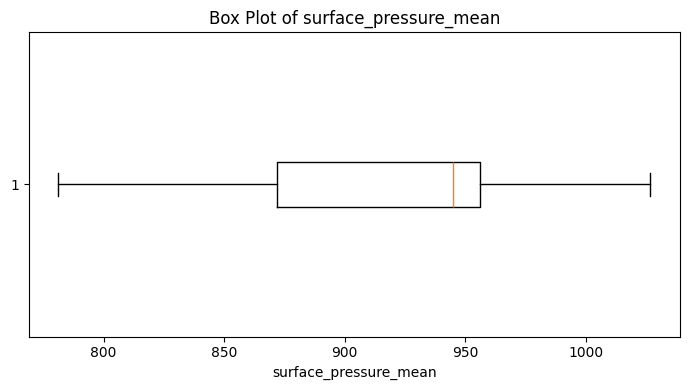

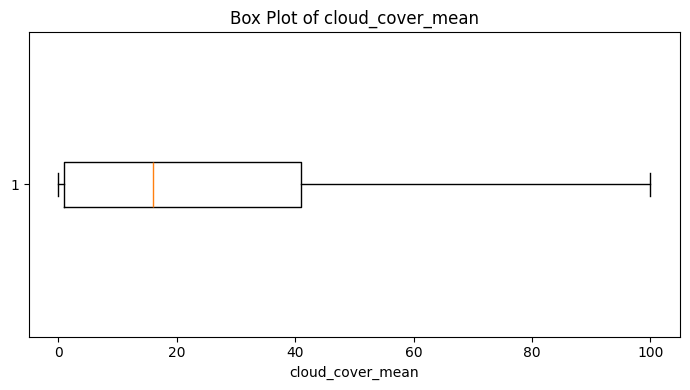

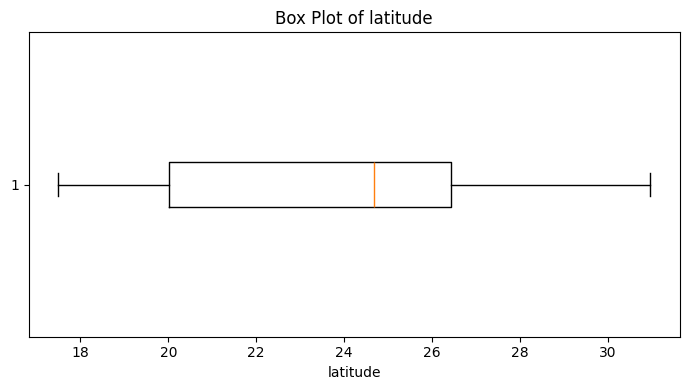

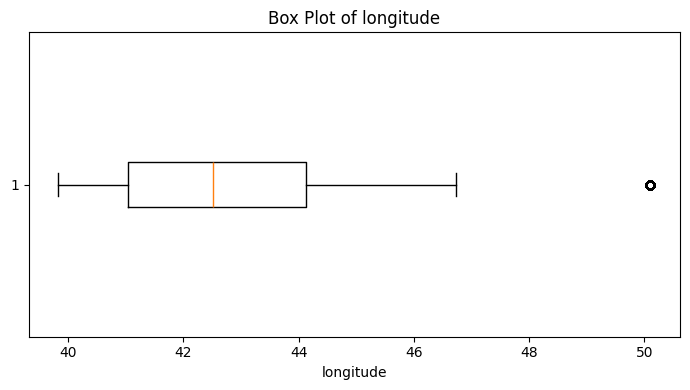

In [11]:
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

# Box plot for each numeric column
for col in numeric_cols:
    plt.figure(figsize=(7, 4))
    plt.boxplot(df[col].dropna(), vert=False)
    plt.title(f'Box Plot of {col}')
    plt.xlabel(col)
    plt.tight_layout()
    plt.show()

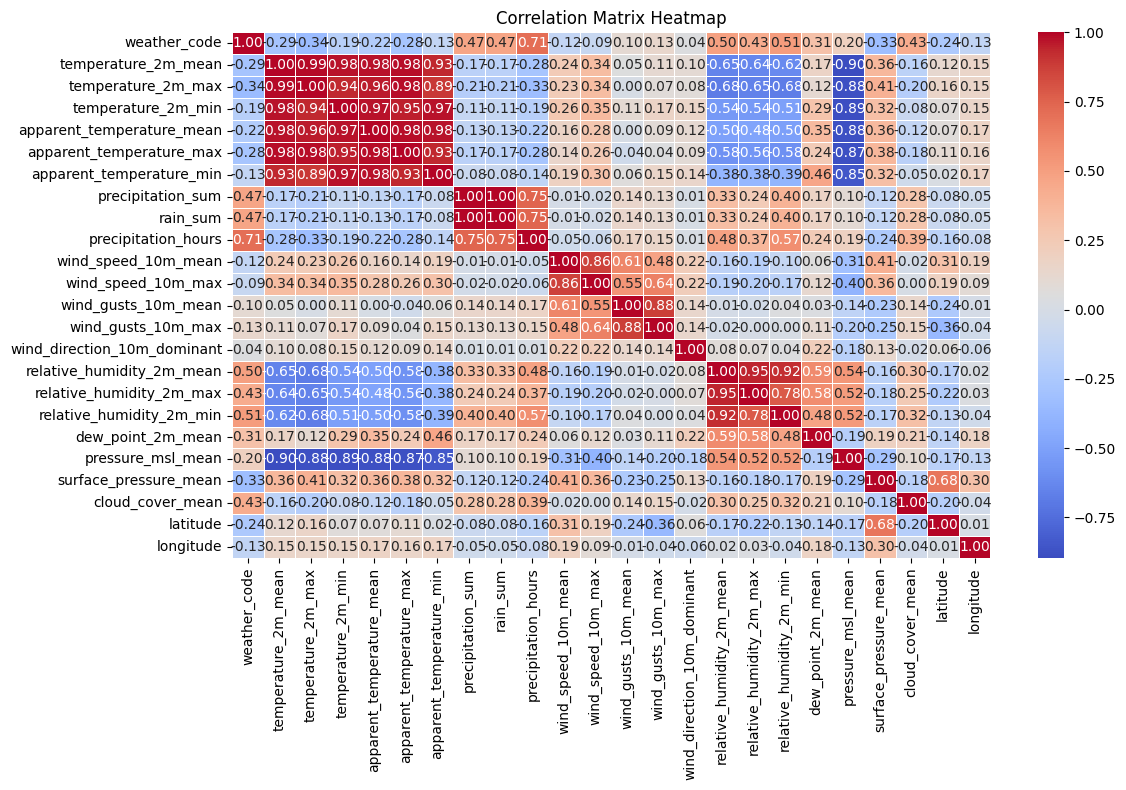

In [12]:
# Select numeric columns
numeric_df = df.select_dtypes(include=['int64', 'float64'])

# Correlation matrix
corr_matrix = numeric_df.corr()

# Visual heatmap
plt.figure(figsize=(12, 8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5
)

plt.title('Correlation Matrix Heatmap')
plt.tight_layout()
plt.show()

In [13]:
numeric_cols = df.select_dtypes(include="number").columns

outlier_summary = []

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = ((df[col] < lower_bound) | (df[col] > upper_bound)).sum()

    outlier_summary.append({
        "column": col,
        "lower_bound": lower_bound,
        "upper_bound": upper_bound,
        "outlier_count": outliers,
        "outlier_percentage": round((outliers / len(df)) * 100, 2)
    })

outlier_summary_df = pd.DataFrame(outlier_summary)
outlier_summary_df.sort_values("outlier_percentage", ascending=False)

,column,lower_bound,upper_bound,outlier_count,outlier_percentage
0,weather_code,-4.500000e+00,7.50000,5624,19.01
7,precipitation_sum,0.000000e+00,0.00000,5624,19.01
9,precipitation_hours,0.000000e+00,0.00000,5624,19.01
8,rain_sum,0.000000e+00,0.00000,5624,19.01
23,longitude,3.640371e+01,48.76203,3287,11.11
17,relative_humidity_2m_min,-2.000000e+01,60.00000,966,3.27
12,wind_gusts_10m_mean,5.650000e+00,43.65000,878,2.97
10,wind_speed_10m_mean,-1.500000e-01,23.45000,607,2.05
13,wind_gusts_10m_max,1.020000e+01,69.40000,543,1.84
11,wind_speed_10m_max,2.750000e+00,37.55000,464,1.57
